## Notebook Goal

Given customer_churn and customer_churn_mini dataset, explore the data and make a model that predict customers who are most likely to cancel their subscripton

In [184]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

In [185]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [186]:
customer_churn_mini_path = '/content/drive/MyDrive/Colab Notebooks/customer churn - thmanyah task/customer_churn_mini.json'
customer_churn_path = '/content/drive/MyDrive/Colab Notebooks/customer churn - thmanyah task/customer_churn.json'

### Exploratory Data Analysis (EDA)

In [187]:
customer_churn_mini = pd.read_json(customer_churn_mini_path, lines=True)

customer_churn_mini.head()

,ts,userId,sessionId,page,auth,method,status,level,itemInSession,location,userAgent,lastName,firstName,registration,gender,artist,song,length
0,1538352117000,30,29,NextSong,Logged In,PUT,200,paid,50,"Bakersfield, CA",Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,Freeman,Colin,1.538173e+12,M,Martha Tilston,Rockpools,277.89016
1,1538352180000,9,8,NextSong,Logged In,PUT,200,free,79,"Boston-Cambridge-Newton, MA-NH","""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",Long,Micah,1.538332e+12,M,Five Iron Frenzy,Canada,236.09424
2,1538352394000,30,29,NextSong,Logged In,PUT,200,paid,51,"Bakersfield, CA",Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,Freeman,Colin,1.538173e+12,M,Adam Lambert,Time For Miracles,282.82730
3,1538352416000,9,8,NextSong,Logged In,PUT,200,free,80,"Boston-Cambridge-Newton, MA-NH","""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",Long,Micah,1.538332e+12,M,Enigma,Knocking On Forbidden Doors,262.71302
4,1538352676000,30,29,NextSong,Logged In,PUT,200,paid,52,"Bakersfield, CA",Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,Freeman,Colin,1.538173e+12,M,Daft Punk,Harder Better Faster Stronger,223.60771


In [188]:
customer_churn = pd.read_json(customer_churn_path, lines=True)

customer_churn.head()

,ts,userId,sessionId,page,auth,method,status,level,itemInSession,location,userAgent,lastName,firstName,registration,gender,artist,song,length
0,1538352011000,293,292,NextSong,Logged In,PUT,200,free,20,"Corpus Christi, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Morales,Joseph,1.532064e+12,M,Martin Orford,Grand Designs,597.55057
1,1538352025000,98,97,NextSong,Logged In,PUT,200,free,74,"Houston-The Woodlands-Sugar Land, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Larson,Sawyer,1.538070e+12,M,John Brown's Body,Bulls,380.21179
2,1538352118000,179,178,NextSong,Logged In,PUT,200,paid,184,"Orlando-Kissimmee-Sanford, FL","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Santiago,Maverick,1.535953e+12,M,Afroman,Because I Got High,202.37016
3,1538352119000,179,178,Logout,Logged In,PUT,307,paid,185,"Orlando-Kissimmee-Sanford, FL","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Santiago,Maverick,1.535953e+12,M,NaN,NaN,NaN
4,1538352124000,246,245,NextSong,Logged In,PUT,200,paid,22,"Mobile, AL",Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,Campos,Gianna,1.535931e+12,F,Lily Allen,Smile (Radio Edit),194.53342


In [189]:
customer_churn_mini.columns, customer_churn.columns

(Index(['ts', 'userId', 'sessionId', 'page', 'auth', 'method', 'status',
        'level', 'itemInSession', 'location', 'userAgent', 'lastName',
        'firstName', 'registration', 'gender', 'artist', 'song', 'length'],
       dtype='object'),
 Index(['ts', 'userId', 'sessionId', 'page', 'auth', 'method', 'status',
        'level', 'itemInSession', 'location', 'userAgent', 'lastName',
        'firstName', 'registration', 'gender', 'artist', 'song', 'length'],
       dtype='object'))

In [190]:
customer_churn_mini.columns == customer_churn.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

In [191]:
customer_churn_mini.dtypes, customer_churn.dtypes

(ts                 int64
 userId            object
 sessionId          int64
 page              object
 auth              object
 method            object
 status             int64
 level             object
 itemInSession      int64
 location          object
 userAgent         object
 lastName          object
 firstName         object
 registration     float64
 gender            object
 artist            object
 song              object
 length           float64
 dtype: object,
 ts                 int64
 userId            object
 sessionId          int64
 page              object
 auth              object
 method            object
 status             int64
 level             object
 itemInSession      int64
 location          object
 userAgent         object
 lastName          object
 firstName         object
 registration     float64
 gender            object
 artist            object
 song              object
 length           float64
 dtype: object)

- Both dataframes have the same columns and datatypes

In [192]:
customer_churn_mini.shape, customer_churn.shape

((286500, 18), (543705, 18))

- `customer_churn` has almost half the data than `customer_churn`

In [193]:
print(customer_churn_mini.isna().sum().sort_values(ascending=False))

artist           58392
length           58392
song             58392
lastName          8346
gender            8346
location          8346
userAgent         8346
registration      8346
firstName         8346
ts                   0
userId               0
itemInSession        0
status               0
level                0
page                 0
auth                 0
sessionId            0
method               0
dtype: int64


In [194]:
print(customer_churn.isna().sum().sort_values(ascending=False))

artist           110828
length           110828
song             110828
lastName          15700
gender            15700
location          15700
userAgent         15700
registration      15700
firstName         15700
ts                    0
userId                0
itemInSession         0
status                0
level                 0
page                  0
auth                  0
sessionId             0
method                0
dtype: int64


In [195]:
# Describing all the Numerical Features
customer_churn.describe()

,ts,sessionId,status,itemInSession,registration,length
count,5.437050e+05,543705.000000,543705.000000,543705.000000,5.280050e+05,432877.000000
mean,1.540965e+12,2040.814353,210.018291,107.306291,1.535523e+12,248.664593
std,1.482057e+09,1434.338931,31.471919,116.723508,3.078725e+09,98.412670
min,1.538352e+12,1.000000,200.000000,0.000000,1.509854e+12,0.783220
25%,1.539720e+12,630.000000,200.000000,26.000000,1.534368e+12,199.392200
50%,1.541005e+12,1968.000000,200.000000,68.000000,1.536556e+12,234.004440
75%,1.542177e+12,3307.000000,200.000000,147.000000,1.537612e+12,276.793020
max,1.543622e+12,4808.000000,404.000000,1005.000000,1.543074e+12,3024.665670


it's an event log of some sort, for each user activity? like log out next page?

- ts: time stamp
- sessionId: id, is catogorial but in numbers
- status: http status, is catogorial but numbers
- itemInSession: even counter for each session
- registration: unique for each customer, is catogorial but numbers
- length: session lenght

In [196]:
# convert some data types based on their intended meaning
customer_churn['ts'] = pd.to_datetime(customer_churn['ts'], unit='ms', errors='coerce')
customer_churn['registration'] = pd.to_datetime(customer_churn['registration'], unit='ms', errors='coerce')
customer_churn['sessionId'] = customer_churn['sessionId'].astype('category')
customer_churn['status'] = customer_churn['status'].astype('category')

In [197]:
# Re deescribe all the Numerical Features
customer_churn.describe()

,ts,itemInSession,registration,length
count,543705,543705.000000,528005,432877.000000
mean,2018-10-31 05:42:21.209824256,107.306291,2018-08-29 06:16:54.863919872,248.664593
min,2018-10-01 00:00:11,0.000000,2017-11-05 03:56:33,0.783220
25%,2018-10-16 20:02:28,26.000000,2018-08-15 21:16:37,199.392200
50%,2018-10-31 16:51:58,68.000000,2018-09-10 05:04:41,234.004440
75%,2018-11-14 06:22:30,147.000000,2018-09-22 10:25:35,276.793020
max,2018-12-01 00:01:06,1005.000000,2018-11-24 15:37:54,3024.665670
std,NaN,116.723508,NaN,98.412670


In [198]:
# Describing all the Categorical Features
customer_churn.describe(include=['O'])

,userId,page,auth,method,level,location,userAgent,lastName,firstName,gender,artist,song
count,543705,543705,543705,543705,543705,528005,528005,528005,528005,528005,432877,432877
unique,449,22,4,2,2,192,71,275,345,2,21247,80292
top,,NextSong,Logged In,PUT,paid,"New York-Newark-Jersey City, NY-NJ-PA","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Reed,Joseph,M,Kings Of Leon,You're The One
freq,15700,432877,527906,495143,428597,40156,46082,12767,13108,302612,3497,2219


- userId: uniqe user id for each customer?
- page: possible events
- method: http method
- level: paid or free
- location: user's location
- userAgent: user's device
- last name
- first name
- gender
- artist
- song

In [199]:
customer_churn.describe(include=['object', 'category', 'datetime']).T

,count,unique,top,freq,mean,min,25%,50%,75%,max
ts,543705,NaN,NaN,NaN,2018-10-31 05:42:21.209824256,2018-10-01 00:00:11,2018-10-16 20:02:28,2018-10-31 16:51:58,2018-11-14 06:22:30,2018-12-01 00:01:06
userId,543705,449,,15700,NaN,NaN,NaN,NaN,NaN,NaN
sessionId,543705.0,4590.0,1052.0,1006.0,NaN,NaN,NaN,NaN,NaN,NaN
page,543705,22,NextSong,432877,NaN,NaN,NaN,NaN,NaN,NaN
auth,543705,4,Logged In,527906,NaN,NaN,NaN,NaN,NaN,NaN
method,543705,2,PUT,495143,NaN,NaN,NaN,NaN,NaN,NaN
status,543705.0,3.0,200.0,493269.0,NaN,NaN,NaN,NaN,NaN,NaN
level,543705,2,paid,428597,NaN,NaN,NaN,NaN,NaN,NaN
location,528005,192,"New York-Newark-Jersey City, NY-NJ-PA",40156,NaN,NaN,NaN,NaN,NaN,NaN
userAgent,528005,71,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",46082,NaN,NaN,NaN,NaN,NaN,NaN


In [200]:
# check it timestamp is unique
total_rows = len(customer_churn)
unique_ts = customer_churn['ts'].nunique()
print(f"Total rows: {total_rows}, Unique timestamps: {unique_ts}")

Total rows: 543705, Unique timestamps: 513108


In [201]:
# see duplicates
duplicates = customer_churn[customer_churn.duplicated(subset=['ts'], keep=False)]
print(len(duplicates))

59950


In [202]:
duplicates.head()

,ts,userId,sessionId,page,auth,method,status,level,itemInSession,location,userAgent,lastName,firstName,registration,gender,artist,song,length
21,2018-10-01 00:07:15,175,442,NextSong,Logged In,PUT,200,free,108,"El Campo, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_...",Castaneda,Lacey,2018-09-21 13:20:32,F,Crazy Frog,Popcorn (Radio Mix),169.50812
22,2018-10-01 00:07:15,98,97,Roll Advert,Logged In,GET,200,free,76,"Houston-The Woodlands-Sugar Land, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Larson,Sawyer,2018-09-27 17:33:58,M,NaN,NaN,NaN
23,2018-10-01 00:07:40,100,497,NextSong,Logged In,PUT,200,free,2,"Dallas-Fort Worth-Arlington, TX",Mozilla/5.0 (Windows NT 6.1; WOW64; rv:30.0) G...,Larson,Colin,2018-09-26 17:17:35,M,The Strokes,You Only Live Once,187.34975
24,2018-10-01 00:07:40,100,497,Roll Advert,Logged In,GET,200,free,3,"Dallas-Fort Worth-Arlington, TX",Mozilla/5.0 (Windows NT 6.1; WOW64; rv:30.0) G...,Larson,Colin,2018-09-26 17:17:35,M,NaN,NaN,NaN
27,2018-10-01 00:09:34,246,245,NextSong,Logged In,PUT,200,paid,24,"Mobile, AL",Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,Campos,Gianna,2018-09-02 23:30:18,F,The Script,Breakeven,260.67546


- it is not unique for each customer, like with user id 100 same timestamp for 2 different events

In [203]:
customer_churn['ts'].value_counts().head()

,count
ts,
2018-11-21 01:39:23,4
2018-11-27 09:59:28,4
2018-11-02 14:55:10,4
2018-10-29 23:43:05,4
2018-10-08 18:15:08,4


In [204]:
customer_churn.groupby('userId')['ts'].nunique().head()

,ts
userId,
,15597
10,421
100,3984
100001,133
100002,176


In [205]:
dupes = customer_churn.duplicated(subset=['userId', 'ts'], keep=False)
customer_churn[dupes].sort_values(['userId', 'ts']).head()


,ts,userId,sessionId,page,auth,method,status,level,itemInSession,location,userAgent,lastName,firstName,registration,gender,artist,song,length
404549,2018-10-01 05:26:32,,49,Home,Logged Out,GET,200,free,114,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
404550,2018-10-01 05:26:32,,49,About,Logged Out,GET,200,free,115,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
1385,2018-10-01 06:44:51,,492,Home,Logged Out,GET,200,paid,16,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
1386,2018-10-01 06:44:51,,492,About,Logged Out,GET,200,paid,17,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
470261,2018-10-02 19:58:52,,104,Help,Logged Out,GET,200,free,4,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN


- there is no one variable that makes each row unique, there might be a combination of varialbes

In [206]:
# check if there are duplicate rows
customer_churn.duplicated().sum()

np.int64(0)

In [207]:
# double check if userId and ts are not unique
customer_churn.duplicated(subset=['userId', 'ts']).sum()

np.int64(1521)

In [208]:
customer_churn.duplicated(subset=['userId', 'sessionId', 'ts']).sum()

np.int64(1505)

In [209]:
customer_churn.duplicated(subset=['userId', 'sessionId', 'ts', 'page']).sum()

np.int64(81)

In [210]:
customer_churn.duplicated(subset=['userId', 'sessionId', 'ts', 'itemInSession']).sum()

np.int64(0)

In [211]:
customer_churn.duplicated(subset=['userId', 'ts', 'itemInSession']).sum()

np.int64(0)

In [212]:
customer_churn.duplicated(subset=['userId', 'itemInSession']).sum()

np.int64(426474)

In [213]:
customer_churn.duplicated(subset=['userId', 'sessionId', 'itemInSession']).sum()

np.int64(175)

- the unique identifier for eadh row (primary key) is the combination : (userId, ts, itemInSession)

- see possible values for some column

In [214]:
customer_churn['page'].unique()

array(['NextSong', 'Logout', 'Home', 'Login', 'Downgrade',
       'Add to Playlist', 'Roll Advert', 'Thumbs Up', 'Help',
       'Thumbs Down', 'Add Friend', 'About', 'Settings', 'Save Settings',
       'Upgrade', 'Submit Downgrade', 'Cancel',
       'Cancellation Confirmation', 'Submit Upgrade', 'Error', 'Register',
       'Submit Registration'], dtype=object)

In [215]:
customer_churn['auth'].unique()

array(['Logged In', 'Logged Out', 'Cancelled', 'Guest'], dtype=object)

In [216]:
customer_churn['method'].unique()

array(['PUT', 'GET'], dtype=object)

In [217]:
customer_churn['status'].unique()

[200, 307, 404]
Categories (3, int64): [200, 307, 404]

In [218]:
customer_churn['level'].unique()

array(['free', 'paid'], dtype=object)

In [219]:
customer_churn.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543705 entries, 0 to 543704
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   ts             543705 non-null  datetime64[ns]
 1   userId         543705 non-null  object        
 2   sessionId      543705 non-null  category      
 3   page           543705 non-null  object        
 4   auth           543705 non-null  object        
 5   method         543705 non-null  object        
 6   status         543705 non-null  category      
 7   level          543705 non-null  object        
 8   itemInSession  543705 non-null  int64         
 9   location       528005 non-null  object        
 10  userAgent      528005 non-null  object        
 11  lastName       528005 non-null  object        
 12  firstName      528005 non-null  object        
 13  registration   528005 non-null  datetime64[ns]
 14  gender         528005 non-null  object        
 15  

In [220]:
customer_churn.head()

,ts,userId,sessionId,page,auth,method,status,level,itemInSession,location,userAgent,lastName,firstName,registration,gender,artist,song,length
0,2018-10-01 00:00:11,293,292,NextSong,Logged In,PUT,200,free,20,"Corpus Christi, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Morales,Joseph,2018-07-20 05:11:47,M,Martin Orford,Grand Designs,597.55057
1,2018-10-01 00:00:25,98,97,NextSong,Logged In,PUT,200,free,74,"Houston-The Woodlands-Sugar Land, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Larson,Sawyer,2018-09-27 17:33:58,M,John Brown's Body,Bulls,380.21179
2,2018-10-01 00:01:58,179,178,NextSong,Logged In,PUT,200,paid,184,"Orlando-Kissimmee-Sanford, FL","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Santiago,Maverick,2018-09-03 05:44:15,M,Afroman,Because I Got High,202.37016
3,2018-10-01 00:01:59,179,178,Logout,Logged In,PUT,307,paid,185,"Orlando-Kissimmee-Sanford, FL","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Santiago,Maverick,2018-09-03 05:44:15,M,NaN,NaN,NaN
4,2018-10-01 00:02:04,246,245,NextSong,Logged In,PUT,200,paid,22,"Mobile, AL",Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,Campos,Gianna,2018-09-02 23:30:18,F,Lily Allen,Smile (Radio Edit),194.53342


- check for null and missing data

In [221]:
customer_churn.isna().sum().sort_values(ascending=False)


,0
artist,110828
length,110828
song,110828
lastName,15700
gender,15700
location,15700
userAgent,15700
registration,15700
firstName,15700
ts,0


- combination of missing firstName, lastName, regitration, userAgent, location and gender could be for guest users

In [222]:
guest_mask = customer_churn[['firstName','lastName','registration','userAgent','location','gender']].isna().all(axis=1)
guest_mask.sum()

np.int64(15700)

In [223]:
customer_churn['auth'].value_counts(dropna=False)

,count
auth,
Logged In,527906
Logged Out,15606
Cancelled,99
Guest,94


In [224]:
guest_auth_check = customer_churn.loc[guest_mask, 'auth'].value_counts()
print(guest_auth_check)

auth
Logged Out    15606
Guest            94
Name: count, dtype: int64


In [225]:
15606+94

15700

In [226]:
user_auth_counts = customer_churn.groupby(['userId'])['auth'].unique()
user_auth_counts

,auth
userId,
,"[Logged Out, Guest]"
10,"[Logged In, Cancelled]"
100,[Logged In]
100001,"[Logged In, Cancelled]"
100002,[Logged In]
...,...
95,[Logged In]
96,[Logged In]
97,[Logged In]


In [227]:
user_auth_counts.loc['']

array(['Logged Out', 'Guest'], dtype=object)

In [228]:
logged_users = customer_churn[customer_churn['auth'] == 'Logged In']['userId'].unique()
customer_churn = customer_churn[customer_churn['userId'].isin(logged_users)]
customer_churn


,ts,userId,sessionId,page,auth,method,status,level,itemInSession,location,userAgent,lastName,firstName,registration,gender,artist,song,length
0,2018-10-01 00:00:11,293,292,NextSong,Logged In,PUT,200,free,20,"Corpus Christi, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Morales,Joseph,2018-07-20 05:11:47,M,Martin Orford,Grand Designs,597.55057
1,2018-10-01 00:00:25,98,97,NextSong,Logged In,PUT,200,free,74,"Houston-The Woodlands-Sugar Land, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Larson,Sawyer,2018-09-27 17:33:58,M,John Brown's Body,Bulls,380.21179
2,2018-10-01 00:01:58,179,178,NextSong,Logged In,PUT,200,paid,184,"Orlando-Kissimmee-Sanford, FL","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Santiago,Maverick,2018-09-03 05:44:15,M,Afroman,Because I Got High,202.37016
3,2018-10-01 00:01:59,179,178,Logout,Logged In,PUT,307,paid,185,"Orlando-Kissimmee-Sanford, FL","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Santiago,Maverick,2018-09-03 05:44:15,M,NaN,NaN,NaN
4,2018-10-01 00:02:04,246,245,NextSong,Logged In,PUT,200,paid,22,"Mobile, AL",Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,Campos,Gianna,2018-09-02 23:30:18,F,Lily Allen,Smile (Radio Edit),194.53342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543700,2018-11-30 23:58:36,300010,882,NextSong,Logged In,PUT,200,paid,165,"Dallas-Fort Worth-Arlington, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Jackson,Clayton,2018-09-13 14:47:51,M,Oliver Onions,Dune Buggy,183.50975
543701,2018-11-30 23:58:52,300049,991,NextSong,Logged In,PUT,200,paid,145,"Fresno, CA","""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",Stewart,Daniel,2018-09-21 09:44:24,M,Sheena Easton,Strut (1993 Digital Remaster),239.62077
543702,2018-11-30 23:59:28,300039,916,NextSong,Logged In,PUT,200,paid,31,"Memphis, TN-MS-AR","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Jenkins,Jeremiah,2018-09-06 10:10:38,M,The White Stripes,Jolene [Live],234.97098
543703,2018-11-30 23:59:52,300038,966,NextSong,Logged In,PUT,200,paid,36,"Lakeland-Winter Haven, FL","""Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like...",Reed,Aiden,2018-08-30 08:03:55,M,Hinder,Lips Of An Angel,262.05995


In [229]:
clean_churn = customer_churn[customer_churn['auth'] == 'Logged In'].copy()
print(clean_churn.shape)


(527906, 18)


In [230]:
clean_churn['userId'].nunique(), customer_churn['userId'].nunique()


(448, 448)

In [231]:
customer_churn.isna().sum().sort_values(ascending=False)

,0
artist,95128
length,95128
song,95128
ts,0
userId,0
sessionId,0
status,0
page,0
auth,0
method,0


- removed customers who are logged out or guestt since they are not related to the goal of the project which is finidng out the active current customer who might cancle thier subscriptions

---
- check when artist, length and song are null



In [232]:
na_mask = customer_churn['song'].isna()  # sameworks for artist/length
customer_churn.loc[na_mask, 'page'].value_counts()

,count
page,
Thumbs Up,23826
Home,19089
Add to Playlist,12349
Add Friend,8087
Roll Advert,7773
Logout,5990
Thumbs Down,4911
Downgrade,3811
Settings,2964


In [233]:
customer_churn.loc[~na_mask, 'page'].value_counts()

,count
page,
NextSong,432877


- only NextSong page has not null song, artist and length data

---
- add churn label for useres who confirmed their cancelation

In [234]:
cancelled_users = customer_churn[customer_churn['page'] == 'Cancellation Confirmation']['userId'].unique() # cancelled users
cancelled_users.shape

(99,)

In [235]:
customer_churn['userId'].unique().shape # all users

(448,)

In [236]:
customer_churn['churn'] = customer_churn['userId'].isin(cancelled_users)
customer_churn.head()

,ts,userId,sessionId,page,auth,method,status,level,itemInSession,location,userAgent,lastName,firstName,registration,gender,artist,song,length,churn
0,2018-10-01 00:00:11,293,292,NextSong,Logged In,PUT,200,free,20,"Corpus Christi, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Morales,Joseph,2018-07-20 05:11:47,M,Martin Orford,Grand Designs,597.55057,True
1,2018-10-01 00:00:25,98,97,NextSong,Logged In,PUT,200,free,74,"Houston-The Woodlands-Sugar Land, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Larson,Sawyer,2018-09-27 17:33:58,M,John Brown's Body,Bulls,380.21179,False
2,2018-10-01 00:01:58,179,178,NextSong,Logged In,PUT,200,paid,184,"Orlando-Kissimmee-Sanford, FL","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Santiago,Maverick,2018-09-03 05:44:15,M,Afroman,Because I Got High,202.37016,False
3,2018-10-01 00:01:59,179,178,Logout,Logged In,PUT,307,paid,185,"Orlando-Kissimmee-Sanford, FL","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Santiago,Maverick,2018-09-03 05:44:15,M,NaN,NaN,NaN,False
4,2018-10-01 00:02:04,246,245,NextSong,Logged In,PUT,200,paid,22,"Mobile, AL",Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,Campos,Gianna,2018-09-02 23:30:18,F,Lily Allen,Smile (Radio Edit),194.53342,True


In [237]:
user_labels = customer_churn.groupby('userId')['churn'].max().reset_index()  # 1 if ever cancelled
user_labels['churn'].value_counts(normalize=True)

,proportion
churn,
False,0.779018
True,0.220982


- there is a class imbalance of roughle 1:4
- since there is a minor class imbalance using advanced scores than accuracy is prefereed


In [238]:
user_labels['churn'].value_counts()

,count
churn,
False,349
True,99


- all usres have either churn value confirmed by the page canellation confirmation

<Axes: title={'center': 'Daily Churn Events'}, xlabel='ts'>

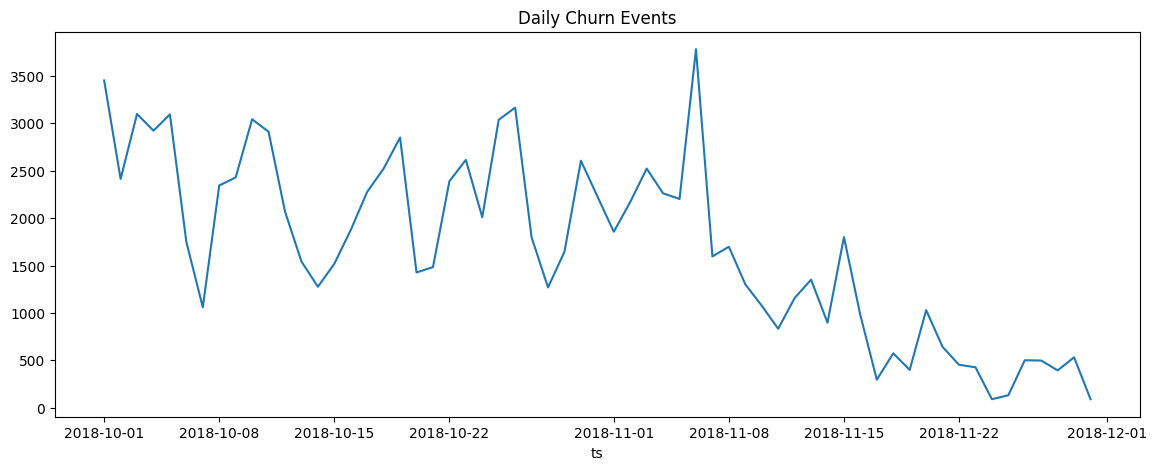

In [239]:
customer_churn[customer_churn['churn']].groupby(customer_churn['ts'].dt.date).size().plot(figsize=(14, 5), title='Daily Churn Events')

- time seems to matter more people cancelled in October and there is a drop in November
---

In [240]:
customer_churn['page'].value_counts().loc[['Cancel','Cancellation Confirmation']]


,count
page,
Cancel,99
Cancellation Confirmation,99


In [241]:
cancel_users = set(customer_churn.loc[customer_churn['page']=='Cancel', 'userId'].unique())
confirm_users = set(customer_churn.loc[customer_churn['page']=='Cancellation Confirmation', 'userId'].unique())

len(cancel_users), len(confirm_users), cancel_users == confirm_users

(99, 99, True)

- every person passed through cancel page went to confirm their cancelation
- since it's redundent, no need to use cancel as an indicator for churn as well as confirm cancelation
---

- check for temporal leakage

In [242]:
cancelled_users_df = customer_churn[customer_churn['userId'].isin(cancelled_users)]
cancelled_users_df.groupby('userId')['ts'].max().head()

,ts
userId,
10,2018-10-09 03:22:44
100001,2018-10-02 14:50:59
100003,2018-11-08 07:19:52
100004,2018-10-14 10:13:00
100005,2018-10-06 10:11:19


In [243]:
cancel_time = (
    customer_churn[customer_churn['page'] == 'Cancellation Confirmation']
    .groupby('userId')['ts']
    .max()
)

In [244]:
last_event = cancelled_users_df.groupby('userId')['ts'].max()

comparison = pd.DataFrame({
    'cancel_time': cancel_time,
    'last_event_time': last_event
})
comparison['diff_minutes'] = (comparison['last_event_time'] - comparison['cancel_time']) / pd.Timedelta(minutes=1)
comparison.head()

,cancel_time,last_event_time,diff_minutes
userId,,,
10,2018-10-09 03:22:44,2018-10-09 03:22:44,0.0
100001,2018-10-02 14:50:59,2018-10-02 14:50:59,0.0
100003,2018-11-08 07:19:52,2018-11-08 07:19:52,0.0
100004,2018-10-14 10:13:00,2018-10-14 10:13:00,0.0
100005,2018-10-06 10:11:19,2018-10-06 10:11:19,0.0


In [245]:
comparison['diff_minutes'].describe()

,diff_minutes
count,99.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [246]:
(comparison['diff_minutes'] > 0).sum()

np.int64(0)

- this confirmed there is no events after the user cancelled their subscription, so no temporal data leakage
---


| Check            | Result                                | Notes         |
| ---------------- | ------------------------------------- | ------------- |
| Churn definition | `page == 'Cancellation Confirmation'` | clear trigger |
| Churn rate       | 1:4 small imbalance                |    acceptable |
| Label quality    | no nulls, binary only                 | acceptable           |
| Leakage          | last event ≈ cancellation timestamp   | acceptable          |


---
- recheck numeric features

In [247]:
customer_churn.describe(percentiles=[.05, .25, .5, .75, .95]).T


,count,mean,min,5%,25%,50%,75%,95%,max,std
ts,528005,2018-10-31 06:22:07.748464640,2018-10-01 00:00:11,2018-10-04 01:20:56.800000,2018-10-16 20:50:19,2018-10-31 17:29:33,2018-11-14 06:49:35,2018-11-28 00:44:48.800000,2018-12-01 00:01:06,NaN
itemInSession,528005.0,107.778995,0.0,4.0,27.0,68.0,148.0,349.0,1005.0,116.864787
registration,528005,2018-08-29 06:16:54.863919616,2017-11-05 03:56:33,2018-06-15 01:29:59,2018-08-15 21:16:37,2018-09-10 05:04:41,2018-09-22 10:25:35,2018-09-30 06:42:56,2018-11-24 15:37:54,NaN
length,432877.0,248.664593,0.78322,138.16118,199.3922,234.00444,276.79302,402.76591,3024.66567,98.41267


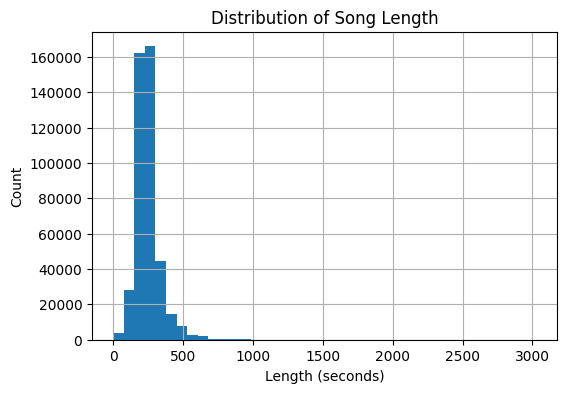

In [248]:
plt.figure(figsize=(6,4))
customer_churn['length'].hist(bins=40)
plt.title('Distribution of Song Length')
plt.xlabel('Length (seconds)')
plt.ylabel('Count')
plt.show()

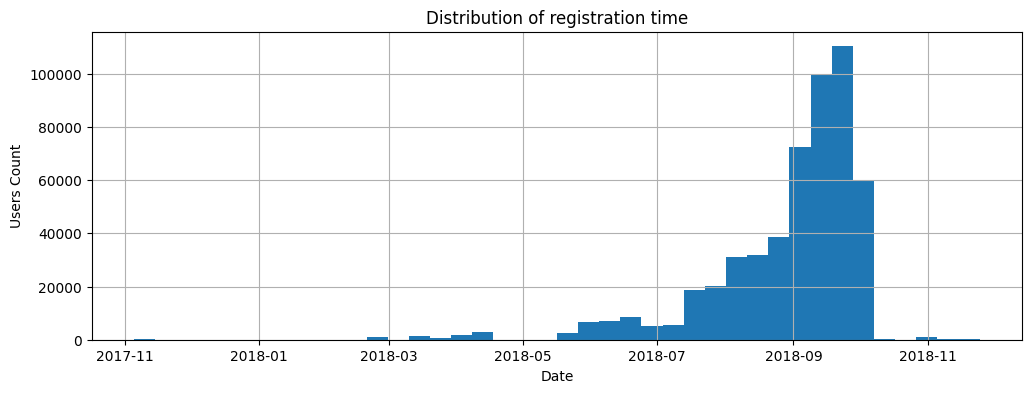

In [249]:
plt.figure(figsize=(12,4))
customer_churn['registration'].hist(bins=40)
plt.title('Distribution of registration time')
plt.xlabel('Date')
plt.ylabel('Users Count')
plt.show()

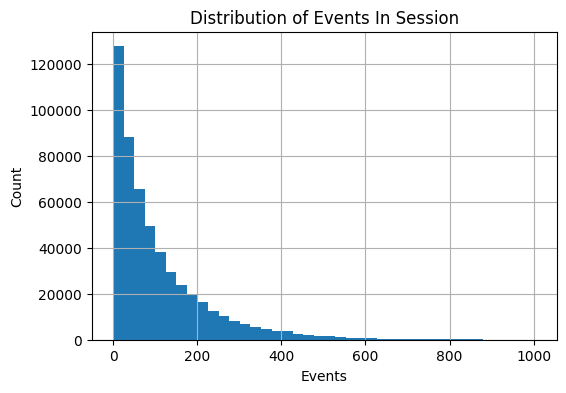

In [250]:
plt.figure(figsize=(6,4))
customer_churn['itemInSession'].hist(bins=40)
plt.title('Distribution of Events In Session')
plt.xlabel('Events')
plt.ylabel('Count')
plt.show()

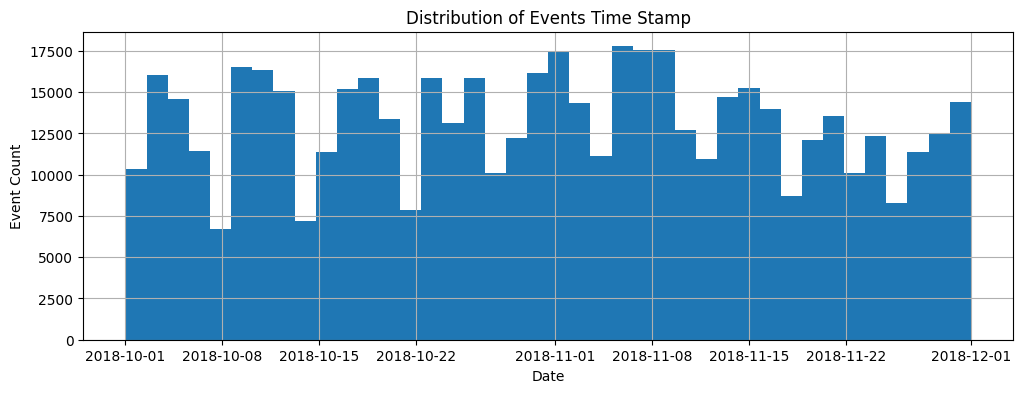

In [251]:
plt.figure(figsize=(12,4))
customer_churn['ts'].hist(bins=40)
plt.title('Distribution of Events Time Stamp')
plt.xlabel('Date')
plt.ylabel('Event Count')
plt.show()

---
- recheck categorical features

In [252]:
customer_churn.columns

Index(['ts', 'userId', 'sessionId', 'page', 'auth', 'method', 'status',
       'level', 'itemInSession', 'location', 'userAgent', 'lastName',
       'firstName', 'registration', 'gender', 'artist', 'song', 'length',
       'churn'],
      dtype='object')

In [253]:
for col in ['page','auth','method','level','gender','level','location','userAgent']:
    vc = customer_churn[col].value_counts(dropna=False, normalize=True)*100
    print(f'\n{col}\n{vc.head(10).round(2)}')


page
page
NextSong           81.98
Thumbs Up           4.51
Home                3.62
Add to Playlist     2.34
Add Friend          1.53
Roll Advert         1.47
Logout              1.13
Thumbs Down         0.93
Downgrade           0.72
Settings            0.56
Name: proportion, dtype: float64

auth
auth
Logged In    99.98
Cancelled     0.02
Name: proportion, dtype: float64

method
method
PUT    92.64
GET     7.36
Name: proportion, dtype: float64

level
level
paid    79.17
free    20.83
Name: proportion, dtype: float64

gender
gender
M    57.31
F    42.69
Name: proportion, dtype: float64

level
level
paid    79.17
free    20.83
Name: proportion, dtype: float64

location
location
New York-Newark-Jersey City, NY-NJ-PA    7.61
Los Angeles-Long Beach-Anaheim, CA       6.49
Boston-Cambridge-Newton, MA-NH           3.33
Chicago-Naperville-Elgin, IL-IN-WI       2.88
San Francisco-Oakland-Hayward, CA        2.16
Atlanta-Sandy Springs-Roswell, GA        2.12
Phoenix-Mesa-Scottsdale, AZ          

- `page` is dominated by `NextPage` which is what normally happens when users are listening to music
- `auth` already created a churn label, so this can be dropped
- `method` HTTP method can be dropped, it's not an indicator for churn
- `gender` is slightly more male, but is mostly balanced none the less
- `level` almost 80% are paid users, lever transitions can be a good sign for churn
- `location` is a long tail variable, all in the US though
- `userAgent` can be simplified


In [254]:
customer_churn = customer_churn.drop(columns=['method', 'auth'])

In [255]:
user_level_transition = (
    customer_churn.groupby('userId')['level']
    .nunique()
    .gt(1)
    .reset_index(name='has_level_transition')
)

customer_churn = customer_churn.merge(user_level_transition, on='userId', how='left')

In [256]:
customer_churn['has_level_transition'].mean()

np.float64(0.7596102309637219)

In [257]:
customer_churn['location'].unique()

array(['Corpus Christi, TX', 'Houston-The Woodlands-Sugar Land, TX',
       'Orlando-Kissimmee-Sanford, FL', 'Mobile, AL', 'Rochester, MN',
       'El Campo, TX', 'Dallas-Fort Worth-Arlington, TX',
       'Los Angeles-Long Beach-Anaheim, CA',
       'Charlotte-Concord-Gastonia, NC-SC',
       'Virginia Beach-Norfolk-Newport News, VA-NC', 'Auburn, IN',
       'Spokane-Spokane Valley, WA',
       'New York-Newark-Jersey City, NY-NJ-PA', 'Tallahassee, FL',
       'Denver-Aurora-Lakewood, CO',
       'Miami-Fort Lauderdale-West Palm Beach, FL', 'Madison, WI',
       'Chicago-Naperville-Elgin, IL-IN-WI', 'Knoxville, TN',
       'New Philadelphia-Dover, OH', 'Richmond, VA',
       'San Francisco-Oakland-Hayward, CA', 'Durham-Chapel Hill, NC',
       'Kingsport-Bristol-Bristol, TN-VA', 'Danville, VA',
       'Kansas City, MO-KS', 'Atlanta-Sandy Springs-Roswell, GA',
       'Phoenix-Mesa-Scottsdale, AZ', 'McAllen-Edinburg-Mission, TX',
       'Quincy, IL-MO', 'Lexington-Fayette, KY',
       'G

In [258]:
top_cities = customer_churn['location'].value_counts().nlargest(10).index
customer_churn['location_simplified'] = customer_churn['location'].apply(
    lambda x: x if x in top_cities else 'Other'
)

In [259]:
customer_churn['location_simplified'].value_counts(normalize=True)*100
customer_churn.head()

,ts,userId,sessionId,page,status,level,itemInSession,location,userAgent,lastName,firstName,registration,gender,artist,song,length,churn,has_level_transition,location_simplified
0,2018-10-01 00:00:11,293,292,NextSong,200,free,20,"Corpus Christi, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Morales,Joseph,2018-07-20 05:11:47,M,Martin Orford,Grand Designs,597.55057,True,True,Other
1,2018-10-01 00:00:25,98,97,NextSong,200,free,74,"Houston-The Woodlands-Sugar Land, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Larson,Sawyer,2018-09-27 17:33:58,M,John Brown's Body,Bulls,380.21179,False,True,"Houston-The Woodlands-Sugar Land, TX"
2,2018-10-01 00:01:58,179,178,NextSong,200,paid,184,"Orlando-Kissimmee-Sanford, FL","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Santiago,Maverick,2018-09-03 05:44:15,M,Afroman,Because I Got High,202.37016,False,False,Other
3,2018-10-01 00:01:59,179,178,Logout,307,paid,185,"Orlando-Kissimmee-Sanford, FL","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Santiago,Maverick,2018-09-03 05:44:15,M,NaN,NaN,NaN,False,False,Other
4,2018-10-01 00:02:04,246,245,NextSong,200,paid,22,"Mobile, AL",Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,Campos,Gianna,2018-09-02 23:30:18,F,Lily Allen,Smile (Radio Edit),194.53342,True,True,Other


In [260]:

def simplify_user_agent(ua):
    if pd.isna(ua): return 'Unknown'
    ua = ua.lower()
    if 'iphone' in ua: return 'iPhone'
    if 'ipad' in ua: return 'iPad'
    if 'android' in ua: return 'Android'
    if 'mac' in ua: return 'Mac'
    if 'windows' in ua: return 'Windows'
    if 'linux' in ua: return 'Linux'
    return 'Other'

In [261]:
customer_churn['device_type'] = customer_churn['userAgent'].apply(simplify_user_agent)
customer_churn['device_type'].value_counts(normalize=True)*100


,proportion
device_type,
Windows,51.217886
Mac,38.268388
Linux,4.740107
iPad,3.031032
iPhone,2.742588


In [262]:
customer_churn[['level','has_level_transition','location_simplified','device_type']].head()

,level,has_level_transition,location_simplified,device_type
0,free,True,Other,Mac
1,free,True,"Houston-The Woodlands-Sugar Land, TX",Mac
2,paid,False,Other,Mac
3,paid,False,Other,Mac
4,paid,True,Other,Windows


---
- check user life span

In [263]:
user_activity = customer_churn.groupby('userId')['ts'].agg(['min','max'])
user_activity['tenure_days'] = (user_activity['max'] - user_activity['min']).dt.days
user_activity['tenure_days'].describe(percentiles=[.05,.25,.5,.75,.95])

,tenure_days
count,448.000000
mean,41.015625
std,18.714199
min,0.000000
5%,0.350000
25%,29.000000
50%,47.000000
75%,56.000000
95%,60.000000
max,60.000000


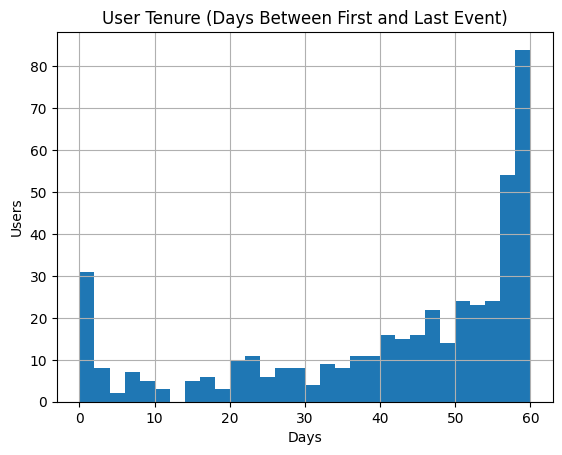

In [264]:
user_activity['tenure_days'].hist(bins=30)
plt.title('User Tenure (Days Between First and Last Event)')
plt.xlabel('Days')
plt.ylabel('Users')
plt.show()

In [265]:
user_activity = user_activity.reset_index()
customer_churn = customer_churn.merge(user_activity[['userId','tenure_days']], on='userId', how='left')

In [266]:
customer_churn.columns

Index(['ts', 'userId', 'sessionId', 'page', 'status', 'level', 'itemInSession',
       'location', 'userAgent', 'lastName', 'firstName', 'registration',
       'gender', 'artist', 'song', 'length', 'churn', 'has_level_transition',
       'location_simplified', 'device_type', 'tenure_days'],
      dtype='object')

- most users have long tenure above the mean

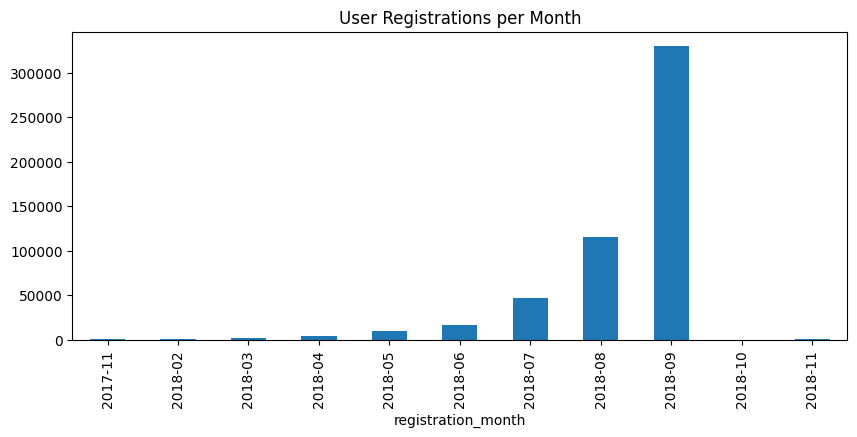

In [267]:
customer_churn['registration_month'] = customer_churn['registration'].dt.to_period('M')
customer_churn['registration_month'].value_counts().sort_index().plot(kind='bar', figsize=(10,4))
plt.title('User Registrations per Month')
plt.show()

In [268]:
customer_churn['registration'].min(), customer_churn['registration'].max()

(Timestamp('2017-11-05 03:56:33'), Timestamp('2018-11-24 15:37:54'))

- most users registerd in September

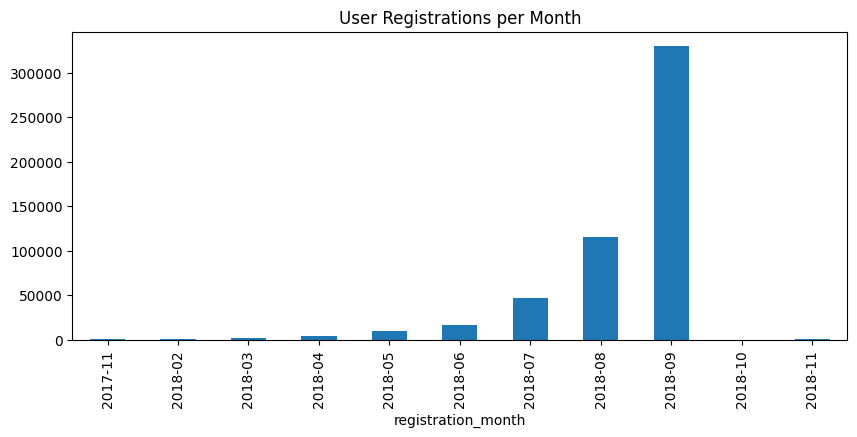

In [269]:
customer_churn['registration_month'] = customer_churn['registration'].dt.to_period('M')
customer_churn['registration_month'].value_counts().sort_index().plot(kind='bar', figsize=(10,4))
plt.title('User Registrations per Month')
plt.show()

<Axes: title={'center': 'Churn Events per Month'}, xlabel='churn_month'>

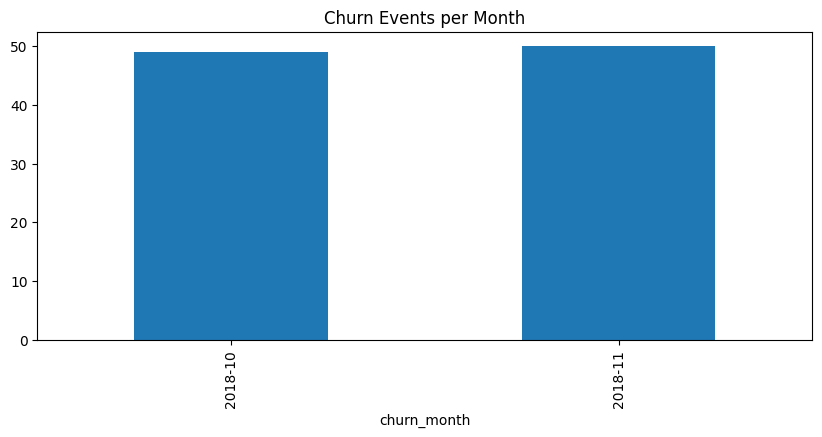

In [270]:
churn_events = customer_churn[customer_churn['page'] == 'Cancellation Confirmation'].copy()
churn_events['churn_month'] = churn_events['ts'].dt.to_period('M')
churn_events['churn_month'].value_counts().sort_index().plot(kind='bar', figsize=(10,4), title='Churn Events per Month')

In [271]:
churn_events['churn_month'].min(), churn_events['churn_month'].max()

(Period('2018-10', 'M'), Period('2018-11', 'M'))

- churn events only happened in 10 and 11
- since registeraion covers a largest span than cancelation, training set could be 10 October and 11 November can be for testing

---
- now the goal is to check which variables effects churn mostly - Bivariate with Target

In [272]:
customer_churn.columns

Index(['ts', 'userId', 'sessionId', 'page', 'status', 'level', 'itemInSession',
       'location', 'userAgent', 'lastName', 'firstName', 'registration',
       'gender', 'artist', 'song', 'length', 'churn', 'has_level_transition',
       'location_simplified', 'device_type', 'tenure_days',
       'registration_month'],
      dtype='object')

In [273]:
for c in ['gender','level','has_level_transition','location_simplified','device_type', 'itemInSession']:
    print(f'\n{c}\n', customer_churn.groupby(c)['churn'].mean().round(3))


gender
 gender
F    0.214
M    0.183
Name: churn, dtype: float64

level
 level
free    0.250
paid    0.182
Name: churn, dtype: float64

has_level_transition
 has_level_transition
False    0.144
True     0.213
Name: churn, dtype: float64

location_simplified
 location_simplified
Atlanta-Sandy Springs-Roswell, GA        0.398
Boston-Cambridge-Newton, MA-NH           0.006
Chicago-Naperville-Elgin, IL-IN-WI       0.373
Dallas-Fort Worth-Arlington, TX          0.140
Denver-Aurora-Lakewood, CO               0.015
Houston-The Woodlands-Sugar Land, TX     0.000
Los Angeles-Long Beach-Anaheim, CA       0.223
New York-Newark-Jersey City, NY-NJ-PA    0.326
Other                                    0.192
Phoenix-Mesa-Scottsdale, AZ              0.023
San Francisco-Oakland-Hayward, CA        0.169
Name: churn, dtype: float64

device_type
 device_type
Linux      0.196
Mac        0.190
Windows    0.203
iPad       0.000
iPhone     0.390
Name: churn, dtype: float64

itemInSession
 itemInSession
0     

- the above is event biased because each row representa an event not a user, and the goal of the project is to find out which users are most likely to cancel
- convert the df to be about users who cancelled

In [274]:
user_churn = customer_churn.groupby('userId')['churn'].max().rename('churn_user')
user_churn.head()

,churn_user
userId,
10,True
100,False
100001,True
100002,False
100003,True


In [275]:
user_churn.shape

(448,)

In [276]:
attrs = (
    customer_churn.sort_values(['userId','ts'])
      .groupby('userId')
      .agg(
          gender=('gender','last'),
          level=('level','last'),
          has_level_transition=('has_level_transition','max'),
          location_simplified=('location_simplified','last'),
          device_type=('device_type', lambda s: s.mode().iat[0] if not s.mode().empty else 'Other'),
          itemInSession=('itemInSession','max')
      )
)

In [277]:
users = attrs.join(user_churn)
users.head()

,gender,level,has_level_transition,location_simplified,device_type,itemInSession,churn_user
userId,,,,,,,
10,M,paid,False,Other,Mac,435,True
100,M,paid,True,"Dallas-Fort Worth-Arlington, TX",Windows,463,False
100001,F,free,False,Other,Mac,64,True
100002,F,free,True,Other,Windows,94,False
100003,F,paid,True,Other,Windows,406,True


In [278]:
def churn_table(col):
    return (users.groupby(col)['churn_user']
                 .agg(rate='mean', n_users='size')
                 .sort_values('rate', ascending=False))

In [279]:
print(churn_table('gender'))

            rate  n_users
gender                   
F       0.227273      198
M       0.216000      250


In [280]:
print(churn_table('level'))

           rate  n_users
level                   
paid   0.242754      276
free   0.186047      172


In [281]:
print(churn_table('has_level_transition'))

                          rate  n_users
has_level_transition                   
True                  0.238683      243
False                 0.200000      205


In [282]:
print(churn_table('location_simplified'))

                                           rate  n_users
location_simplified                                     
Atlanta-Sandy Springs-Roswell, GA      0.444444        9
Chicago-Naperville-Elgin, IL-IN-WI     0.368421       19
New York-Newark-Jersey City, NY-NJ-PA  0.266667       30
Denver-Aurora-Lakewood, CO             0.250000        4
Los Angeles-Long Beach-Anaheim, CA     0.233333       30
Dallas-Fort Worth-Arlington, TX        0.222222        9
Other                                  0.209524      315
San Francisco-Oakland-Hayward, CA      0.200000       10
Boston-Cambridge-Newton, MA-NH         0.142857        7
Phoenix-Mesa-Scottsdale, AZ            0.125000        8
Houston-The Woodlands-Sugar Land, TX   0.000000        7


In [283]:
print(churn_table('device_type'))

                 rate  n_users
device_type                   
iPhone       0.611111       18
Windows      0.216216      222
Mac          0.202312      173
Linux        0.192308       26
iPad         0.000000        9


In [284]:
tbl = churn_table('device_type')
tbl[tbl['n_users'] >= 50]

,rate,n_users
device_type,,
Windows,0.216216,222
Mac,0.202312,173


In [285]:
tbl = churn_table('location_simplified')
tbl[tbl['n_users'] >= 50]

,rate,n_users
location_simplified,,
Other,0.209524,315


- overall churn rate for all users (≈22%) <- baseline
- `location_simplified` dose not seem to effect churn
- `device_type` also dose not seem to effect churn
- **`has_level_transition`** is slightly different than baseline, so it may have an effect
- **`level`** seems to have a strong effect churn, paid users seems to churn more
- `gender` dose not seem to effect churn

---
- check numerical columns effects on churn
- add more numerical columns to `users` df based on `churn_customer` df

In [286]:
user_tenure = (
    customer_churn.groupby('userId')['ts']
    .agg(first_ts='min', last_ts='max')
    .assign(tenure_days=lambda d: (d['last_ts'] - d['first_ts']).dt.days)
)[['tenure_days']]
user_tenure.head()

,tenure_days
userId,
10,1
100,60
100001,1
100002,23
100003,29


In [287]:
plays = customer_churn[customer_churn['page'] == 'NextSong']
plays.head()

,ts,userId,sessionId,page,status,level,itemInSession,location,userAgent,lastName,...,gender,artist,song,length,churn,has_level_transition,location_simplified,device_type,tenure_days,registration_month
0,2018-10-01 00:00:11,293,292,NextSong,200,free,20,"Corpus Christi, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Morales,...,M,Martin Orford,Grand Designs,597.55057,True,True,Other,Mac,51,2018-07
1,2018-10-01 00:00:25,98,97,NextSong,200,free,74,"Houston-The Woodlands-Sugar Land, TX","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Larson,...,M,John Brown's Body,Bulls,380.21179,False,True,"Houston-The Woodlands-Sugar Land, TX",Mac,60,2018-09
2,2018-10-01 00:01:58,179,178,NextSong,200,paid,184,"Orlando-Kissimmee-Sanford, FL","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Santiago,...,M,Afroman,Because I Got High,202.37016,False,False,Other,Mac,60,2018-09
4,2018-10-01 00:02:04,246,245,NextSong,200,paid,22,"Mobile, AL",Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,Campos,...,F,Lily Allen,Smile (Radio Edit),194.53342,True,True,Other,Windows,34,2018-09
5,2018-10-01 00:02:05,163,162,NextSong,200,paid,266,"Rochester, MN","""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",Gordon,...,F,Carter USM,Airplane Food,138.29179,False,False,Other,Mac,60,2018-08


In [288]:
user_music = plays.groupby('userId').agg(
    songs_played=('song','count'),
    avg_song_length=('length','mean'),
    total_listen_time=('length','sum')
)
user_music.head()

,songs_played,avg_song_length,total_listen_time
userId,,,
10,360,251.456780,90524.44076
100,3382,245.342499,829748.33112
100001,96,247.868118,23795.33930
100002,137,268.387307,36769.06108
100003,661,245.525946,162292.65050


In [289]:
users = (
    users.join(user_tenure)
         .join(user_music)
         .dropna(subset=['tenure_days'])
)

In [290]:
users.head()

,gender,level,has_level_transition,location_simplified,device_type,itemInSession,churn_user,tenure_days,songs_played,avg_song_length,total_listen_time
userId,,,,,,,,,,,
10,M,paid,False,Other,Mac,435,True,1,360,251.456780,90524.44076
100,M,paid,True,"Dallas-Fort Worth-Arlington, TX",Windows,463,False,60,3382,245.342499,829748.33112
100001,F,free,False,Other,Mac,64,True,1,96,247.868118,23795.33930
100002,F,free,True,Other,Windows,94,False,23,137,268.387307,36769.06108
100003,F,paid,True,Other,Windows,406,True,29,661,245.525946,162292.65050


In [291]:
users['tenure_bin'] = pd.qcut(users['tenure_days'], q=5, duplicates='drop')
tenure_tbl = users.groupby('tenure_bin')['churn_user'].mean().to_frame('churn_rate')
print('\nTenure vs Churn\n', tenure_tbl)


Tenure vs Churn
                 churn_rate
tenure_bin                
(-0.001, 23.0]    0.527473
(23.0, 42.0]      0.373626
(42.0, 52.0]      0.125000
(52.0, 57.0]      0.023256
(57.0, 60.0]      0.035714


/tmp/ipython-input-456110329.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_tbl = users.groupby('tenure_bin')['churn_user'].mean().to_frame('churn_rate')


- people with less tenure daya tend to cancel more

In [292]:
users['songs_bin'] = pd.qcut(users['songs_played'], q=5, duplicates='drop')
songs_tbl = users.groupby('songs_bin')['churn_user'].mean().to_frame('churn_rate')
print('\nSongs Played vs Churn\n', songs_tbl)


Songs Played vs Churn
                   churn_rate
songs_bin                   
(0.999, 140.0]      0.230769
(140.0, 373.0]      0.295455
(373.0, 785.0]      0.166667
(785.0, 1626.0]     0.224719
(1626.0, 8177.0]    0.188889


/tmp/ipython-input-1092826540.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  songs_tbl = users.groupby('songs_bin')['churn_user'].mean().to_frame('churn_rate')


In [293]:
users['avglen_bin'] = pd.qcut(users['avg_song_length'], q=5, duplicates='drop')
avglen_tbl = users.groupby('avglen_bin')['churn_user'].mean().to_frame('churn_rate')
print('\nAverage Song Length vs Churn\n', avglen_tbl)


Average Song Length vs Churn
                     churn_rate
avglen_bin                    
(131.003, 244.484]    0.188889
(244.484, 247.345]    0.224719
(247.345, 249.085]    0.222222
(249.085, 251.699]    0.213483
(251.699, 320.812]    0.255556


/tmp/ipython-input-3677920323.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avglen_tbl = users.groupby('avglen_bin')['churn_user'].mean().to_frame('churn_rate')


In [294]:
users['avglen_bin'] = pd.qcut(users['total_listen_time'], q=5, duplicates='drop')
avglen_tbl = users.groupby('avglen_bin')['churn_user'].mean().to_frame('churn_rate')
print('\nTotal Listen Time vs Churn\n', avglen_tbl)


Total Listen Time vs Churn
                            churn_rate
avglen_bin                           
(131.003, 34448.399]         0.244444
(34448.399, 92036.89]        0.269663
(92036.89, 197293.861]       0.177778
(197293.861, 404888.561]     0.224719
(404888.561, 2019435.104]    0.188889


/tmp/ipython-input-2606383069.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avglen_tbl = users.groupby('avglen_bin')['churn_user'].mean().to_frame('churn_rate')


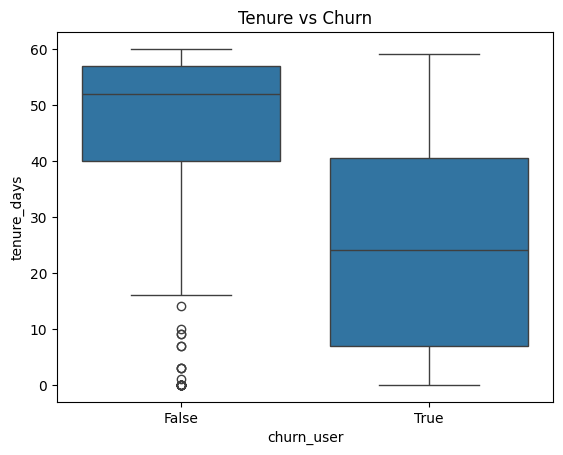

In [295]:
sns.boxplot(x='churn_user', y='tenure_days', data=users)
plt.title('Tenure vs Churn'); plt.show()

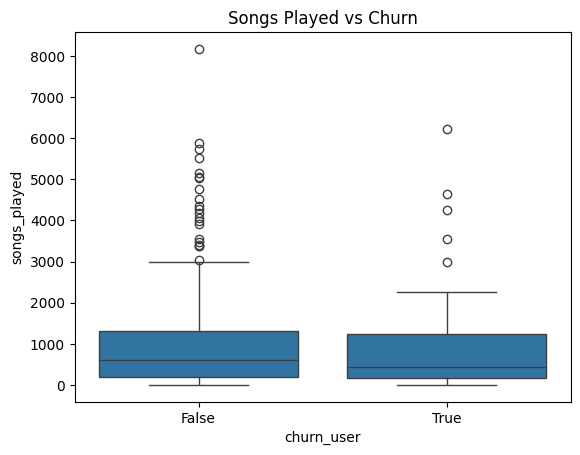

In [296]:
sns.boxplot(x='churn_user', y='songs_played', data=users)
plt.title('Songs Played vs Churn'); plt.show()

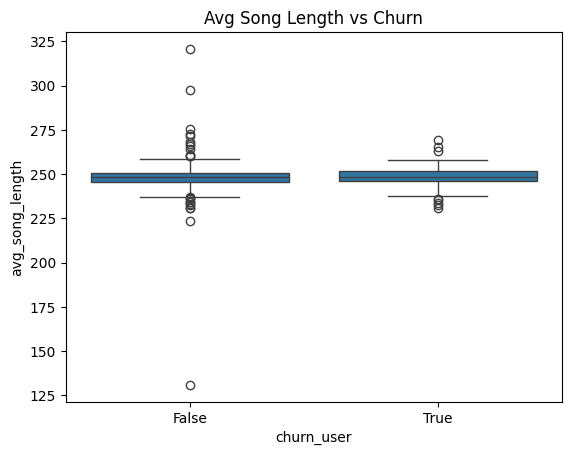

In [297]:
sns.boxplot(x='churn_user', y='avg_song_length', data=users)
plt.title('Avg Song Length vs Churn'); plt.show()

- **`tenure_days`** seems to be the stronges indicator for churn, longer the less likely to cancel
- **`song_played`** seems like a good indicator but with some small noise
- `average_song_length` almost flat, not a an indicator it seems
- **`total_listen_time`** seems like an indicator as well but with some noise, the more the user listen the less likely to cancel


In [298]:
users.groupby('churn_user')[['tenure_days','songs_played','total_listen_time']].mean().round(1)


,tenure_days,songs_played,total_listen_time
churn_user,,,
False,45.6,998.6,248241.5
True,24.8,852.1,212170.5


In [299]:
for c in ['level','has_level_transition']:
    rate = users.groupby(c)['churn_user'].mean().round(3)
    print(f'\n{c}\n{rate}')


level
level
free    0.186
paid    0.243
Name: churn_user, dtype: float64

has_level_transition
has_level_transition
False    0.200
True     0.239
Name: churn_user, dtype: float64


| Feature                | Type        | Signal Strength    | Relationship                  |
| ---------------------- | ----------- | ------------------ | ----------------------------- |
| `tenure_days`          | numeric     | Strong          | Shorter → higher churn        |
| `songs_played`         | numeric     | Moderate–strong | Fewer songs → higher churn    |
| `total_listen_time`    | numeric     | Moderate        | Less listening → higher churn |
| `level`                | categorical | Moderate        | Paid users churn more         |
| `has_level_transition` | categorical | Moderate        | Plan changers churn more      |


<Axes: >

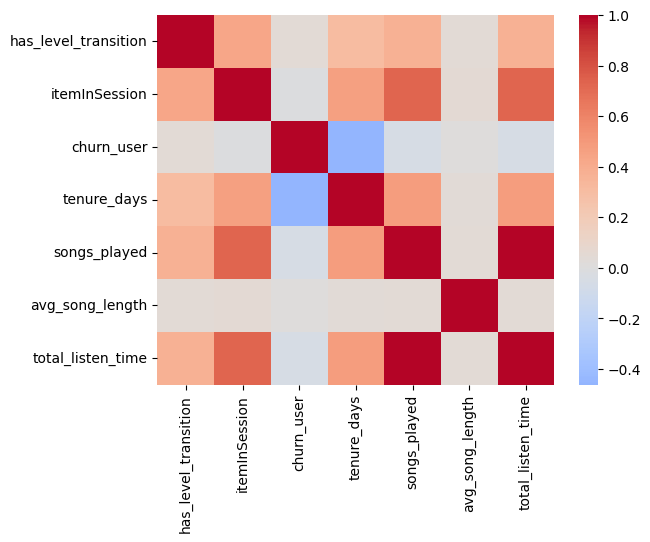

In [300]:
corr = users.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0)

In [301]:
users = users.drop(columns=['itemInSession', 'songs_played'], errors='ignore')

users.info()

<class 'pandas.core.frame.DataFrame'>
Index: 448 entries, 10 to 99
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   gender                448 non-null    object  
 1   level                 448 non-null    object  
 2   has_level_transition  448 non-null    bool    
 3   location_simplified   448 non-null    object  
 4   device_type           448 non-null    object  
 5   churn_user            448 non-null    bool    
 6   tenure_days           448 non-null    int64   
 7   avg_song_length       448 non-null    float64 
 8   total_listen_time     448 non-null    float64 
 9   tenure_bin            448 non-null    category
 10  songs_bin             448 non-null    category
 11  avglen_bin            448 non-null    category
dtypes: bool(2), category(3), float64(2), int64(1), object(4)
memory usage: 47.1+ KB


- `itemInSession` correlate with both `song_played` and `total_listen_time` so i dropped it
- `song_played` correlate strongly with `total_listen_time` so i dropped one

---
- check outliers

In [302]:
# A) Event-level song length (only plays)
plays = customer_churn[customer_churn['page'] == 'NextSong'].copy()

print("\nlength (seconds) percentiles:")
print(plays['length'].describe(percentiles=[.01,.05,.95,.99]))

# sanity checks
print("Any negative lengths?", (plays['length'] < 0).any())
print("Max length (s):", plays['length'].max())

# B) User-level features
num_cols = ['tenure_days', 'total_listen_time', 'avg_song_length']
print("\nUser-level percentiles:")
print(users[num_cols].describe(percentiles=[.01,.05,.95,.99]).T)

# sanity checks
for c in num_cols:
    print(f"{c}: any negatives? ->", (users[c] < 0).any())


length (seconds) percentiles:
count    432877.000000
mean        248.664593
std          98.412670
min           0.783220
1%           80.874650
5%          138.161180
50%         234.004440
95%         402.765910
99%         589.818320
max        3024.665670
Name: length, dtype: float64
Any negative lengths? False
Max length (s): 3024.66567

User-level percentiles:
                   count           mean            std        min  \
tenure_days        448.0      41.015625      18.714199    0.00000   
total_listen_time  448.0  240270.497609  286257.952605  131.00363   
avg_song_length    448.0     248.205979       9.067959  131.00363   

                            1%            5%            50%            95%  \
tenure_days           0.000000      0.350000      47.000000      60.000000   
total_listen_time  3682.021680  10202.885149  136731.830360  834107.460186   
avg_song_length     231.753521    238.060186     248.334466     256.253075   

                            99%         

- remove outliers data, because trusting 99% of data is better than only trusting the 1%

In [303]:
# User-level caps (tenure_days, total_listen_time, avg_song_length) ---
# cap on a copy:
p99_tenure = users['tenure_days'].quantile(0.99)
p99_total  = users['total_listen_time'].quantile(0.99)
p99_avglen = users['avg_song_length'].quantile(0.99)

users['tenure_days_cap']      = users['tenure_days'].clip(lower=0, upper=p99_tenure)
users['total_listen_time_cap']= users['total_listen_time'].clip(lower=0, upper=p99_total)
users['avg_song_length_cap']  = users['avg_song_length'].clip(lower=0, upper=p99_avglen)

print(f"tenure_days p99 = {p99_tenure:.2f} days")
print(f"total_listen_time p99 = {p99_total:.2f} sec")
print(f"avg_song_length p99 = {p99_avglen:.2f} sec")


tenure_days p99 = 60.00 days
total_listen_time p99 = 1327958.07 sec
avg_song_length p99 = 270.51 sec


- make train/test split based on time, because churn is time dependent

In [304]:
customer_churn['ts'] = pd.to_datetime(customer_churn['ts'], errors='coerce')

In [305]:
customer_churn['month'] = customer_churn['ts'].dt.to_period('M')
customer_churn['month'].value_counts().sort_index()

,count
month,
2018-10,268126
2018-11,259875
2018-12,4


In [306]:
last_activity = customer_churn.groupby('userId')['ts'].max().reset_index()
last_activity['month'] = last_activity['ts'].dt.to_period('M')
last_activity

,userId,ts,month
0,10,2018-10-09 03:22:44,2018-10
1,100,2018-11-30 19:34:28,2018-11
2,100001,2018-10-02 14:50:59,2018-10
3,100002,2018-11-02 08:17:40,2018-11
4,100003,2018-11-08 07:19:52,2018-11
...,...,...,...
443,95,2018-11-27 15:07:11,2018-11
444,96,2018-11-26 23:31:23,2018-11
445,97,2018-11-29 06:33:34,2018-11
446,98,2018-11-30 16:17:38,2018-11


In [307]:
users_split = users.merge(last_activity[['userId','month']], on='userId', how='left')
users_split

,userId,gender,level,has_level_transition,location_simplified,device_type,churn_user,tenure_days,avg_song_length,total_listen_time,tenure_bin,songs_bin,avglen_bin,tenure_days_cap,total_listen_time_cap,avg_song_length_cap,month
0,10,M,paid,False,Other,Mac,True,1,251.456780,90524.44076,"(-0.001, 23.0]","(140.0, 373.0]","(34448.399, 92036.89]",1,90524.44076,251.456780,2018-10
1,100,M,paid,True,"Dallas-Fort Worth-Arlington, TX",Windows,False,60,245.342499,829748.33112,"(57.0, 60.0]","(1626.0, 8177.0]","(404888.561, 2019435.104]",60,829748.33112,245.342499,2018-11
2,100001,F,free,False,Other,Mac,True,1,247.868118,23795.33930,"(-0.001, 23.0]","(0.999, 140.0]","(131.003, 34448.399]",1,23795.33930,247.868118,2018-10
3,100002,F,free,True,Other,Windows,False,23,268.387307,36769.06108,"(-0.001, 23.0]","(0.999, 140.0]","(34448.399, 92036.89]",23,36769.06108,268.387307,2018-11
4,100003,F,paid,True,Other,Windows,True,29,245.525946,162292.65050,"(23.0, 42.0]","(373.0, 785.0]","(92036.89, 197293.861]",29,162292.65050,245.525946,2018-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,95,F,paid,False,"Phoenix-Mesa-Scottsdale, AZ",Mac,False,57,250.299874,516118.34017,"(52.0, 57.0]","(1626.0, 8177.0]","(404888.561, 2019435.104]",57,516118.34017,250.299874,2018-11
444,96,F,paid,False,Other,Mac,False,55,250.480905,488437.76410,"(52.0, 57.0]","(1626.0, 8177.0]","(404888.561, 2019435.104]",55,488437.76410,250.480905,2018-11
445,97,F,paid,True,Other,Windows,False,53,249.630186,300305.11331,"(52.0, 57.0]","(785.0, 1626.0]","(197293.861, 404888.561]",53,300305.11331,249.630186,2018-11
446,98,M,paid,True,"Houston-The Woodlands-Sugar Land, TX",Mac,False,60,250.123580,672082.05974,"(57.0, 60.0]","(1626.0, 8177.0]","(404888.561, 2019435.104]",60,672082.05974,250.123580,2018-11


In [308]:
train_users = users_split[users_split['month'] == '2018-10']
test_users  = users_split[users_split['month'] == '2018-11']
train_users.shape, test_users.shape

((65, 17), (379, 17))

In [309]:
train_rate = train_users['churn_user'].mean().round(3)
test_rate  = test_users['churn_user'].mean().round(3)

print(f"Train churn rate: {train_rate}")
print(f"Test churn rate:  {test_rate}")

Train churn rate: 0.754
Test churn rate:  0.132


In [310]:
65/(65+379)

0.1463963963963964

- splitting by last month is skewed, most 75% of October users are churner, and they are less than test data set, only 15% of the data

In [311]:
from sklearn.model_selection import train_test_split

train_users, test_users = train_test_split(
    users, test_size=0.2, stratify=users['churn_user'], random_state=42
)

print(train_users.shape, test_users.shape)
print("Train churn rate:", train_users['churn_user'].mean().round(3))
print("Test churn rate:", test_users['churn_user'].mean().round(3))

(358, 15) (90, 15)
Train churn rate: 0.221
Test churn rate: 0.222


In [312]:
train_users.head()

,gender,level,has_level_transition,location_simplified,device_type,churn_user,tenure_days,avg_song_length,total_listen_time,tenure_bin,songs_bin,avglen_bin,tenure_days_cap,total_listen_time_cap,avg_song_length_cap
userId,,,,,,,,,,,,,,,
300012,M,paid,True,Other,Windows,False,54,246.003356,61992.84568,"(52.0, 57.0]","(140.0, 373.0]","(34448.399, 92036.89]",54,61992.84568,246.003356
197,M,free,False,"Houston-The Woodlands-Sugar Land, TX",Windows,False,37,242.722244,22330.44644,"(23.0, 42.0]","(0.999, 140.0]","(131.003, 34448.399]",37,22330.44644,242.722244
20,F,paid,False,Other,Windows,False,56,249.013535,537371.20774,"(52.0, 57.0]","(1626.0, 8177.0]","(404888.561, 2019435.104]",56,537371.20774,249.013535
221,M,paid,False,"Los Angeles-Long Beach-Anaheim, CA",iPhone,True,40,248.306221,61331.63654,"(23.0, 42.0]","(140.0, 373.0]","(34448.399, 92036.89]",40,61331.63654,248.306221
155,F,paid,False,"Chicago-Naperville-Elgin, IL-IN-WI",Mac,False,23,250.564957,35079.09403,"(-0.001, 23.0]","(0.999, 140.0]","(34448.399, 92036.89]",23,35079.09403,250.564957


In [313]:
train_users['churn_user'].mean(), test_users['churn_user'].mean()

(np.float64(0.2206703910614525), np.float64(0.2222222222222222))

In [314]:
train_users.describe(), test_users.describe()

(       tenure_days  avg_song_length  total_listen_time  tenure_days_cap  \
 count   358.000000       358.000000       3.580000e+02       358.000000   
 mean     41.134078       248.044454       2.497438e+05        41.134078   
 std      19.146316         9.666551       2.942713e+05        19.146316   
 min       0.000000       131.003630       1.310036e+02         0.000000   
 25%      27.250000       245.516079       4.868142e+04        27.250000   
 50%      49.000000       248.298763       1.402553e+05        49.000000   
 75%      57.000000       250.720869       3.488564e+05        57.000000   
 max      60.000000       320.812244       2.019435e+06        60.000000   
 
        total_listen_time_cap  avg_song_length_cap  
 count           3.580000e+02           358.000000  
 mean            2.464747e+05           247.808657  
 std             2.791842e+05             8.577635  
 min             1.310036e+02           131.003630  
 25%             4.868142e+04           245.51607

- 22% churn rate is in both training and testing dataset
- it's 80/20 split

### Feature enineering

In [315]:
y_train = train_users['churn_user'].astype(int)
y_test  = test_users['churn_user'].astype(int)
y_train.shape, y_test.shape

((358,), (90,))

In [316]:
X_train = train_users.drop(columns=['churn_user'])
X_test  = test_users.drop(columns=['churn_user'])
X_train.shape, X_test.shape

((358, 14), (90, 14))

In [317]:
X_train

,gender,level,has_level_transition,location_simplified,device_type,tenure_days,avg_song_length,total_listen_time,tenure_bin,songs_bin,avglen_bin,tenure_days_cap,total_listen_time_cap,avg_song_length_cap
userId,,,,,,,,,,,,,,
300012,M,paid,True,Other,Windows,54,246.003356,61992.84568,"(52.0, 57.0]","(140.0, 373.0]","(34448.399, 92036.89]",54,61992.84568,246.003356
197,M,free,False,"Houston-The Woodlands-Sugar Land, TX",Windows,37,242.722244,22330.44644,"(23.0, 42.0]","(0.999, 140.0]","(131.003, 34448.399]",37,22330.44644,242.722244
20,F,paid,False,Other,Windows,56,249.013535,537371.20774,"(52.0, 57.0]","(1626.0, 8177.0]","(404888.561, 2019435.104]",56,537371.20774,249.013535
221,M,paid,False,"Los Angeles-Long Beach-Anaheim, CA",iPhone,40,248.306221,61331.63654,"(23.0, 42.0]","(140.0, 373.0]","(34448.399, 92036.89]",40,61331.63654,248.306221
155,F,paid,False,"Chicago-Naperville-Elgin, IL-IN-WI",Mac,23,250.564957,35079.09403,"(-0.001, 23.0]","(0.999, 140.0]","(34448.399, 92036.89]",23,35079.09403,250.564957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,M,free,False,Other,Windows,58,241.076041,65572.68318,"(57.0, 60.0]","(140.0, 373.0]","(34448.399, 92036.89]",58,65572.68318,241.076041
79,M,free,False,Other,iPhone,28,253.411462,53976.64137,"(23.0, 42.0]","(140.0, 373.0]","(34448.399, 92036.89]",28,53976.64137,253.411462
19,F,free,False,Other,Windows,17,237.386021,12106.68707,"(-0.001, 23.0]","(0.999, 140.0]","(131.003, 34448.399]",17,12106.68707,237.386021


In [318]:
X_train.columns

Index(['gender', 'level', 'has_level_transition', 'location_simplified',
       'device_type', 'tenure_days', 'avg_song_length', 'total_listen_time',
       'tenure_bin', 'songs_bin', 'avglen_bin', 'tenure_days_cap',
       'total_listen_time_cap', 'avg_song_length_cap'],
      dtype='object')

- columns to keep
  - categorical
    - gender
    - level
    - has_level_transition
    - location_simplified
    - device_type
  - numeric
    - tenure_days_cap
    - avg_song_length_cap
    - total_listen_time_cap

- columns to drop (redundent)
  - total_listen_time
  - avg_song_length
  - tenure_days
  - tenure_bin
  - songs_bin
  - avglen_bin

In [319]:
drop_cols = [
    'tenure_days', 'avg_song_length', 'total_listen_time',
    'tenure_bin', 'songs_bin', 'avglen_bin'
]

In [320]:
X_train = X_train.drop(columns=drop_cols)
X_test  = X_test.drop(columns=drop_cols)

In [321]:
X_train

,gender,level,has_level_transition,location_simplified,device_type,tenure_days_cap,total_listen_time_cap,avg_song_length_cap
userId,,,,,,,,
300012,M,paid,True,Other,Windows,54,61992.84568,246.003356
197,M,free,False,"Houston-The Woodlands-Sugar Land, TX",Windows,37,22330.44644,242.722244
20,F,paid,False,Other,Windows,56,537371.20774,249.013535
221,M,paid,False,"Los Angeles-Long Beach-Anaheim, CA",iPhone,40,61331.63654,248.306221
155,F,paid,False,"Chicago-Naperville-Elgin, IL-IN-WI",Mac,23,35079.09403,250.564957
...,...,...,...,...,...,...,...,...
147,M,free,False,Other,Windows,58,65572.68318,241.076041
79,M,free,False,Other,iPhone,28,53976.64137,253.411462
19,F,free,False,Other,Windows,17,12106.68707,237.386021


In [322]:
numeric_cols = ['tenure_days_cap', 'avg_song_length_cap', 'total_listen_time_cap']
categorical_cols = ['gender', 'level', 'has_level_transition', 'location_simplified', 'device_type']

In [323]:
X_train.isna().sum().sort_values(ascending=False)

,0
gender,0
level,0
has_level_transition,0
location_simplified,0
device_type,0
tenure_days_cap,0
total_listen_time_cap,0
avg_song_length_cap,0


In [324]:
X_test.isna().sum().sort_values(ascending=False)

,0
gender,0
level,0
has_level_transition,0
location_simplified,0
device_type,0
tenure_days_cap,0
total_listen_time_cap,0
avg_song_length_cap,0


- there is no null in the training or testing dataset, but making a pipeline to handle missing and null data would be beneficial for later data, if the model would be used in production

In [325]:
numeric_preproc = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

categorical_preproc = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_preproc, numeric_cols),
    ('cat', categorical_preproc, categorical_cols)
])


### Models training

- preprocess and train the model (logistic regressoin)

In [326]:
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['tenure_days_cap',
                                                   'avg_song_length_cap',
                                                   'total_listen_time_cap']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'level',
                                                   'has_level_transition',
                                                   'location_simplified',
                                                   'device_type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

- evaluate the model

In [327]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        70
           1       0.44      0.55      0.49        20

    accuracy                           0.74        90
   macro avg       0.65      0.68      0.66        90
weighted avg       0.77      0.74      0.75        90

ROC-AUC: 0.8221428571428572


- the model is better at identifying non churners but that is due to imbalance data, because a random guessing model with our data would get non churnere right 78% of the time

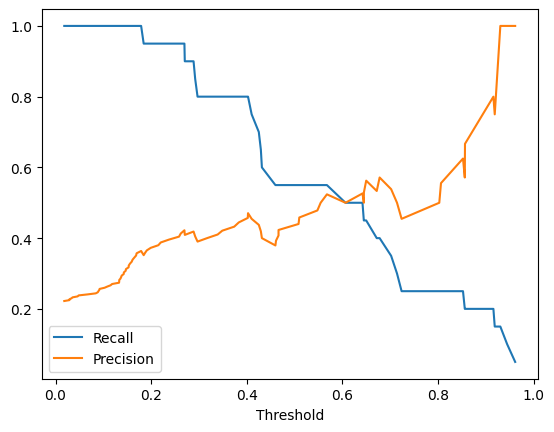

In [328]:
proba = model.predict_proba(X_test)[:, 1]
prec, rec, thr = precision_recall_curve(y_test, proba)

import matplotlib.pyplot as plt
plt.plot(thr, rec[:-1], label='Recall')
plt.plot(thr, prec[:-1], label='Precision')
plt.xlabel('Threshold')
plt.legend()
plt.show()


In [329]:
# predicted probabilities
y_proba = model.predict_proba(X_test)[:, 1]

# custom threshold
threshold = 0.4

#Convert to binary predictions
y_pred_thresh = (y_proba >= threshold).astype(int)

# Evaluate
print("Precision:", precision_score(y_test, y_pred_thresh))
print("Recall:", recall_score(y_test, y_pred_thresh))
print("F1:", f1_score(y_test, y_pred_thresh))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Precision: 0.45714285714285713
Recall: 0.8
F1: 0.5818181818181818
ROC-AUC: 0.8221428571428572


- changing the recall to 0.4 instead of 0.5 made the modle catch more churnesrs, even though the precision is not that different
- but if the goal to catch churners before they cancell, false positeves are less costly than false negatrives

In [330]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_thresh))
print("\nReport:\n", classification_report(y_test, y_pred_thresh, digits=3))

Confusion matrix:
 [[51 19]
 [ 4 16]]

Report:
               precision    recall  f1-score   support

           0      0.927     0.729     0.816        70
           1      0.457     0.800     0.582        20

    accuracy                          0.744        90
   macro avg      0.692     0.764     0.699        90
weighted avg      0.823     0.744     0.764        90



- using logistic regression with 0.4 threshold gave the below resutls
  - Precision: 0.45714285714285713 (how many users did churn)
  - Recall: 0.8 (how many users did the model classify as churners)
  - F1: 0.5818181818181818 (Balance of Precision & Recall)
  - ROC-AUC: 0.8221428571428572 (overall, how well the model seperate churnesr and non-chunrers)
  ---
  try other models

In [337]:
neg, pos = (y_train==0).sum(), (y_train==1).sum()
spw = neg / pos

lgbm = Pipeline([
    ('prep', preprocessor),
    ('clf', LGBMClassifier(
        n_estimators=600, learning_rate=0.05, num_leaves=31,  min_data_in_leaf=10,min_gain_to_split=0.0,
        subsample=0.8, colsample_bytree=0.8,
        class_weight=None,
        scale_pos_weight=spw,
        random_state=42
    ))
])
lgbm.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.0
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.0
[LightGBM] [Info] Number of positive: 79, number of negative: 279
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 311
[LightGBM] [Info] Number of data points in the train set: 358, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.220670 -> initscore=-1.261764
[LightGBM] [Info] Start training from score -1.261764
[LightGBM] [Warning] N

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['tenure_days_cap',
                                                   'avg_song_length_cap',
                                                   'total_listen_time_cap']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'level',
                                                   'has_level_transition',
                                                   'location_simplified',
                                                   'device_type'])])),
                ('clf',
                 LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05,
                                min_data_in_leaf=10, min_gain_to_split=0.0,
                                n_estimators=600, random_state=42,
                                scale_pos_weight=np.float64(3.5316455696202533),
                                subsample=0.8))])

In [332]:
xgb = Pipeline([
    ('prep', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=600, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, eval_metric='auc',
        scale_pos_weight=spw, random_state=42, n_jobs=-1
    ))
])
xgb.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['tenure_days_cap',
                                                   'avg_song_length_cap',
                                                   'total_listen_time_cap']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gen...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=600, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [333]:
rf = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_leaf=3,
        class_weight='balanced_subsample', n_jobs=-1, random_state=42
    ))
])
rf.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['tenure_days_cap',
                                                   'avg_song_length_cap',
                                                   'total_listen_time_cap']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'level',
                                                   'has_level_transition',
                                                   'location_simplified',
                                                   'device_type'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        min_samples_leaf=3, n_estimators=400,
                                        n_jobs=-1, random_state=42))])

In [334]:
lr = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        max_iter=5000, class_weight='balanced', C=0.5, penalty='l2', solver='lbfgs'
    ))
])
lr.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['tenure_days_cap',
                                                   'avg_song_length_cap',
                                                   'total_listen_time_cap']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'level',
                                                   'has_level_transition',
                                                   'location_simplified',
                                                   'device_type'])])),
                ('clf',
                 LogisticRegression(C=0.5, class_weight='balanced',
                                    max_iter=5000))])

In [340]:
def eval_model(m, X_tr, y_tr, X_te, y_te):
    m.fit(X_tr, y_tr)
    p = m.predict_proba(X_te)[:,1]
    return roc_auc_score(y_te, p), average_precision_score(y_te, p)  # PR-AUC

In [341]:

models = {
    'LR': lr,
    'RF': rf,
    'LGBM': lgbm,
    'XGB': xgb
}
models_results = {}
for name, m in models.items():
    roc, pr = eval_model(m, X_train, y_train, X_test, y_test)
    models_results[name] = {"ROC-AUC":roc,"PR-AUC":pr}

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.0
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.0
[LightGBM] [Info] Number of positive: 79, number of negative: 279
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 311
[LightGBM] [Info] Number of data points in the train set: 358, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.220670 -> initscore=-1.261764
[LightGBM] [Info] Start training from score -1.261764
[LightGBM] [Warning] N

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [342]:
models_results

{'LR': {'ROC-AUC': np.float64(0.8228571428571428),
  'PR-AUC': np.float64(0.5611890753950921)},
 'RF': {'ROC-AUC': np.float64(0.8585714285714285),
  'PR-AUC': np.float64(0.6602358780252002)},
 'LGBM': {'ROC-AUC': np.float64(0.8092857142857143),
  'PR-AUC': np.float64(0.6273313265433134)},
 'XGB': {'ROC-AUC': np.float64(0.8164285714285715),
  'PR-AUC': np.float64(0.6364501655613464)}}

In [343]:
c

      ROC-AUC  PR-AUC
LR      0.823   0.561
RF      0.859   0.660
LGBM    0.809   0.627
XGB     0.816   0.636


- Random Forest is the best preformer overall with
  - ROC-AUC = 0.859 (how well it identify churners vs non churners)
  - PR-AUC = 0.660 (how well it idenify the minority (churners))